In [2]:
import pandas as pd

# 读取文本文件
with open(r'C:\Users\owner\Desktop\KG\OneNYC_2050_Strategic_Plan_final.txt', 'r', encoding='utf-8') as file:
    documents = file.readlines()

# 简单预处理（移除空行）
documents = [doc.strip() for doc in documents if doc.strip()]

In [3]:
from nltk.stem import WordNetLemmatizer
import re
from collections import Counter
from nltk.tokenize import word_tokenize
import nltk

# 确保已经下载必要的资源
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# 定义并更新停用词列表
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
stop_words.update(["new", "city", "new york", "york", "public", "community", "communities", "health", "yorker", "yorkers", "state", "onenyc", "2050", "mayor"])

# 初始化词形还原器
lemmatizer = WordNetLemmatizer()

 # 关键词及其近义词集合
extended_seed_topics = {
    'adaptive capacity': ['adaptive','adaptation','adapt', 'adjustment ability', 'adaptation capacity', 'flexibility', 'resilience', 'adaptation', 'coping ability', 'adaptive response', 'climate resilience', 'adaptive management', 'adaptation strategies', 'capacity to adapt', 'system adaptability'],
    'climate proofing': ['climate proofing', 'climate resilience', 'climate adaptation', 'climate change adaptation', 'climate resilience strategies', 'climate protection', 'climate-smart infrastructure', 'resilient infrastructure', 'climate adaptation measures', 'climate change mitigation'],
    'vulnerability assessment': ['vulnerability','vulnerable', 'vulnerability analysis', 'risk assessment', 'impact assessment', 'climate risk evaluation', 'climate vulnerability', 'threat analysis', 'hazard assessment', 'vulnerability mapping', 'climate risk analysis', 'resilience assessment'],
    'ecosystem-based adaptation': ['ecosystem adaptative', 'ecosystem resilience', 'ecosystem change', 'ecosystem', 'ecological adaptation', 'ecosystem response', 'ecological resilience', 'ecosystem transformation', 'environmental adaptation', 'ecosystem sustainability', 'ecosystem-based adaptation', 'ecosystem management'],
    'resilience': ['resilience', 'resilient', 'adaptive capacity', 'toughness', 'durability', 'robustness', 'resiliency', 'recovery ability', 'strength', 'sustainability', 'robust system', 'climate resilience', 'disaster resilience', 'resilient systems', 'adaptive resilience', 'resilience building'],
    'transportation planning': ['transportation planning', 'public transport', 'transportation', 'transport', 'public transit', 'transport infrastructure', 'transportation systems', 'urban transport'],
    'zoning': ['zoning', 'land use regulation', 'urban zoning', 'zoning laws', 'land use planning', 'urban land use', 'land zoning', 'zoning ordinances', 'zoning policies', 'land use regulations', 'zoning codes', 'land use management', 'urban zoning policies', 'spatial zoning'],
    'urban design': ['urban design', 'city planning', 'urban development', 'city design', 'urban form', 'urban planning', 'built environment', 'urban renewal', 'city layout', 'urban architecture', 'urban planning design', 'sustainable urban design', 'urban space design', 'city landscape design'],
    'sustainable development': ['sustainable development', 'sustainability', 'green development', 'sustainable growth', 'eco-friendly development', 'environmental sustainability', 'eco-development', 'green growth', 'environmentally sustainable development', 'sustainable urban development', 'low-carbon development', 'social sustainability', 'economic sustainability', 'sustainability initiatives'],
    'land use planning': ['land use', 'urban land', 'land development', 'land management', 'land allocation', 'urban land use', 'spatial planning', 'land use policies', 'land planning', 'territorial planning', 'land use zoning', 'land use strategy', 'urban land management', 'land use regulations', 'land use planning policies']
}


# 扁平化扩展后的种子主题词汇列表，并进行词形还原
flat_extended_seed_words = []
for sublist in extended_seed_topics.values():
    for word in sublist:
        flat_extended_seed_words.append(lemmatizer.lemmatize(word))

# 处理文档数据：去除空行并分词
documents = [doc.strip() for doc in documents if doc.strip()]
tokenized_docs = [word_tokenize(doc.lower()) for doc in documents]
tokenized_docs = [[word for word in doc if word.isalpha() and word not in stop_words] for doc in tokenized_docs]

# 词形还原每个单词
lemmatized_docs = [[lemmatizer.lemmatize(word) for word in doc] for doc in tokenized_docs]

# 统计每个种子主题词汇在文档中的频率
word_freq = Counter()

# 处理每个文档，使用正则表达式匹配词组
for doc in lemmatized_docs:
    doc_str = ' '.join(doc)  # 将分词后的文档重新合并为字符串
    for phrase, explanation in extended_seed_topics.items():
        for word in explanation:
            # 正则表达式匹配整个词组
            pattern = r'\b' + re.escape(word) + r'\b'
            matches = re.findall(pattern, doc_str)
            word_freq[phrase] += len(matches)

# 打印每个种子主题词汇的出现频率和对应的解释
for phrase, freq in word_freq.items():
    print(f"'{phrase}' ({', '.join(extended_seed_topics[phrase])}): {freq}")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


'adaptive capacity' (adaptive, adaptation, adapt, adjustment ability, adaptation capacity, flexibility, resilience, adaptation, coping ability, adaptive response, climate resilience, adaptive management, adaptation strategies, capacity to adapt, system adaptability): 65
'climate proofing' (climate proofing, climate resilience, climate adaptation, climate change adaptation, climate resilience strategies, climate protection, climate-smart infrastructure, resilient infrastructure, climate adaptation measures, climate change mitigation): 11
'vulnerability assessment' (vulnerability, vulnerable, vulnerability analysis, risk assessment, impact assessment, climate risk evaluation, climate vulnerability, threat analysis, hazard assessment, vulnerability mapping, climate risk analysis, resilience assessment): 42
'ecosystem-based adaptation' (ecosystem adaptative, ecosystem resilience, ecosystem change, ecosystem, ecological adaptation, ecosystem response, ecological resilience, ecosystem transf

In [4]:
import csv
from nltk.tokenize import sent_tokenize
import unicodedata
import re

# 确保已下载必要的资源
nltk.download('punkt')

# 初始化结果存储
results = []

def clean_text(text):
    """清理文本中不可见字符、特殊符号和非 ASCII 字符"""
    # 移除控制字符和不可打印字符
    text = ''.join(c for c in text if unicodedata.category(c)[0] != 'C')
    # 替换所有非 ASCII 字符为一个空格
    text = re.sub(r'[^\x00-\x7F]', ' ', text)
    # 替换多余的空格
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 处理每个文档，按句分割并查找匹配
for doc in documents:
    doc = clean_text(doc)  # 清理文档中的特殊字符
    sentences = sent_tokenize(doc)  # 将文档分割成句子
    for sentence in sentences:
        lemmatized_sentence = [lemmatizer.lemmatize(word.lower()) for word in word_tokenize(sentence) if word.isalpha() and word.lower() not in stop_words]
        lemmatized_sentence_str = ' '.join(lemmatized_sentence)

        for phrase, explanation in extended_seed_topics.items():
            for word in explanation:
                pattern = r'\b' + re.escape(word) + r'\b'
                if re.search(pattern, lemmatized_sentence_str):
                    results.append({
                        'Topic': phrase,
                        'Matched Word': word,
                        'Sentence': sentence
                    })


# 将结果保存到 CSV 文件
csv_file = r"C:\Users\owner\Desktop\KG\matched_sentences.csv"
with open(csv_file, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=['Topic', 'Matched Word', 'Sentence'])
    writer.writeheader()
    writer.writerows(results)

print(f"Results have been saved to {csv_file}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Results have been saved to C:\Users\owner\Desktop\KG\matched_sentences.csv


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


关键词共现矩阵：
                            adaptive capacity  climate proofing  \
adaptive capacity                         0.0               5.0   
climate proofing                          5.0               0.0   
vulnerability assessment                  9.0               4.0   
ecosystem-based adaptation                1.0               0.0   
resilience                               19.0               6.0   
transportation planning                  17.0               5.0   
zoning                                    3.0               1.0   
urban design                              4.0               3.0   
sustainable development                   3.0               2.0   
land use planning                         0.0               0.0   

                            vulnerability assessment  \
adaptive capacity                                9.0   
climate proofing                                 4.0   
vulnerability assessment                         0.0   
ecosystem-based adaptation   

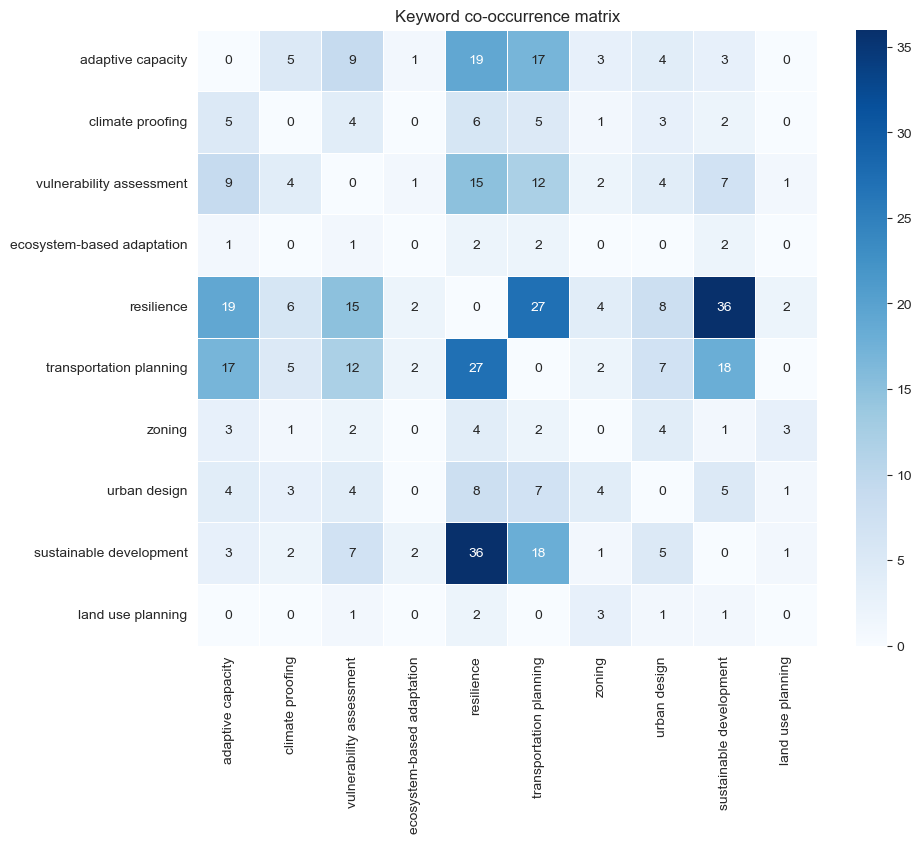

In [5]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# 关键词及其近义词集合
keywords = extended_seed_topics
# 下载nltk所需的资源
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 构建共现矩阵
def build_cooccurrence_matrix(freq, documents, keywords):
    co_matrix = pd.DataFrame(np.zeros((len(keywords), len(keywords))),
                             index=keywords.keys(), columns=keywords.keys())

    for document in documents:
        found_keywords = set()  # 存储当前文档中出现的关键词
        for main_keyword, syns in keywords.items():
            pattern = r'\b(?:' + '|'.join(syns) + r')\b'
            if re.search(pattern, document.lower()):
                found_keywords.add(main_keyword)

        # 更新共现矩阵
        for kw1 in found_keywords:
            for kw2 in found_keywords:
                if kw1 != kw2:
                    co_matrix.at[kw1, kw2] += 1

    return co_matrix

# 生成共现矩阵
cooccurrence_matrix = build_cooccurrence_matrix(freq, documents, extended_seed_topics)

print("关键词共现矩阵：")
print(cooccurrence_matrix)

# 可视化共现矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_matrix, annot=True, cmap='Blues', fmt='g', linewidths=0.5)
plt.title("Keyword co-occurrence matrix")
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


关键词共现矩阵（频率版）：
                            adaptive capacity  climate proofing  \
adaptive capacity                    0.000000          0.010799   
climate proofing                     0.010799          0.000000   
vulnerability assessment             0.019438          0.008639   
ecosystem-based adaptation           0.002160          0.000000   
resilience                           0.041037          0.012959   
transportation planning              0.036717          0.010799   
zoning                               0.006479          0.002160   
urban design                         0.008639          0.006479   
sustainable development              0.006479          0.004320   
land use planning                    0.000000          0.000000   

                            vulnerability assessment  \
adaptive capacity                           0.019438   
climate proofing                            0.008639   
vulnerability assessment                    0.000000   
ecosystem-based adaptati

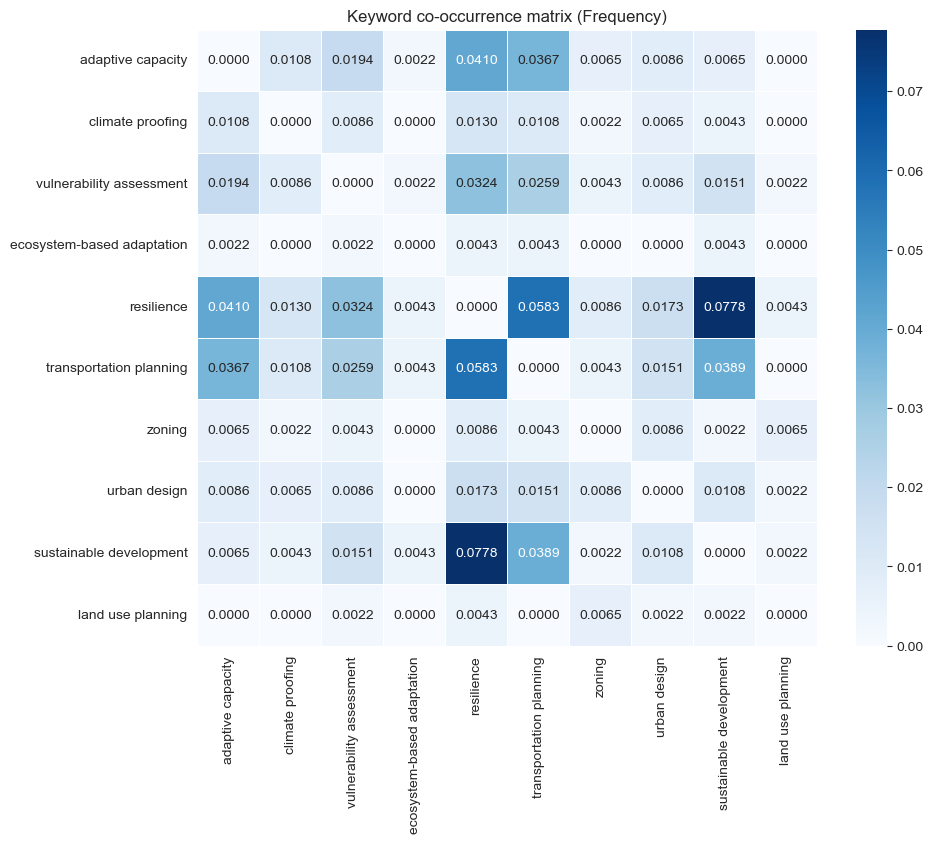

In [6]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# 关键词及其近义词集合
keywords = extended_seed_topics

# 下载nltk所需的资源
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 构建共现矩阵（频率版）
def build_cooccurrence_matrix(freq, documents, keywords):
    co_matrix = pd.DataFrame(np.zeros((len(keywords), len(keywords))),
                             index=keywords.keys(), columns=keywords.keys())
    total_documents = len(documents)  # 总文档数

    for document in documents:
        found_keywords = set()  # 存储当前文档中出现的关键词
        for main_keyword, syns in keywords.items():
            pattern = r'\b(?:' + '|'.join(syns) + r')\b'
            if re.search(pattern, document.lower()):
                found_keywords.add(main_keyword)

        # 更新共现矩阵
        for kw1 in found_keywords:
            for kw2 in found_keywords:
                if kw1 != kw2:
                    co_matrix.at[kw1, kw2] += 1

    # 将每个元素的次数除以文档总数，计算频率
    co_matrix = co_matrix / total_documents

    return co_matrix

# 生成共现矩阵
cooccurrence_matrix = build_cooccurrence_matrix(freq, documents, extended_seed_topics)

print("关键词共现矩阵（频率版）：")
print(cooccurrence_matrix)

# 可视化共现矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(cooccurrence_matrix, annot=True, cmap='Blues', fmt='.4f', linewidths=0.5)  # 显示4位小数
plt.title("Keyword co-occurrence matrix (Frequency)")
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


每个关键词的频率：
{'adaptive capacity': 0.07775377969762419, 'transportation planning': 0.1900647948164147, 'sustainable development': 0.09935205183585313, 'resilience': 0.20518358531317496, 'vulnerability assessment': 0.0734341252699784, 'climate proofing': 0.01511879049676026, 'land use planning': 0.01511879049676026, 'zoning': 0.02591792656587473, 'ecosystem-based adaptation': 0.023758099352051837, 'urban design': 0.04103671706263499}


C:\Users\owner\AppData\Local\Temp\ipykernel_22128\1472624586.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keywords_list, y=frequencies, palette='Blues_d')


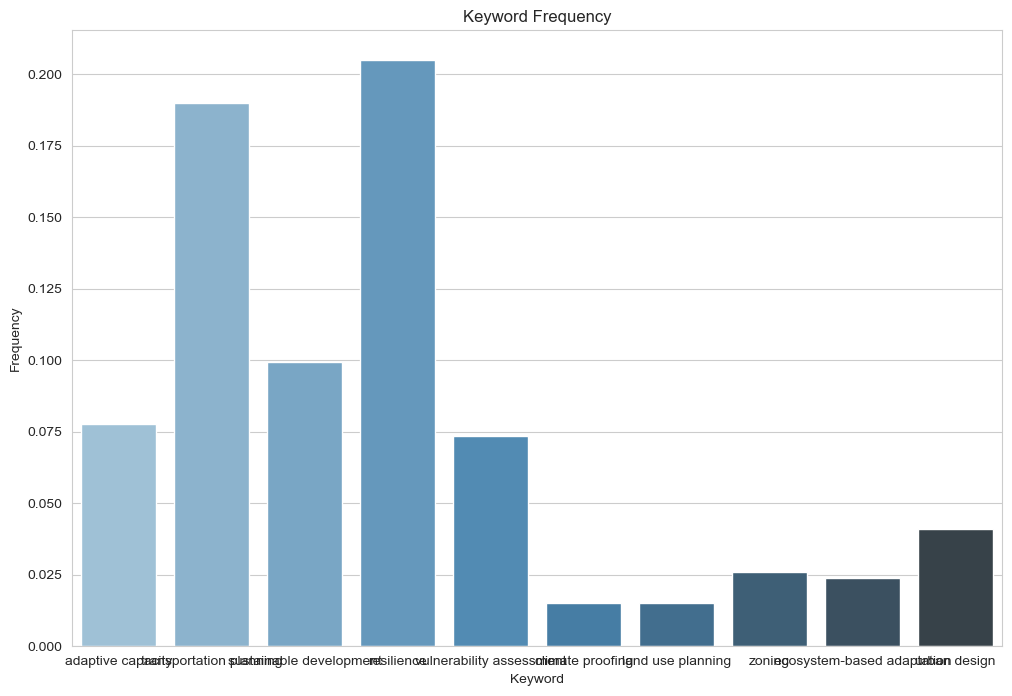

In [7]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

# 关键词及其近义词集合
keywords = extended_seed_topics

# 下载nltk所需的资源
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# 构建关键词的频率（频率版）
def build_keyword_frequency(documents, keywords):
    keyword_freq = defaultdict(int)  # 用于存储每个关键词的出现次数
    total_documents = len(documents)  # 总文档数

    for document in documents:
        found_keywords = set()  # 存储当前文档中出现的关键词
        for main_keyword, syns in keywords.items():
            pattern = r'\b(?:' + '|'.join(syns) + r')\b'
            if re.search(pattern, document.lower()):
                found_keywords.add(main_keyword)

        # 更新关键词频率
        for kw in found_keywords:
            keyword_freq[kw] += 1

    # 将每个关键词的出现次数除以文档总数，得到频率
    keyword_frequency = {kw: freq / total_documents for kw, freq in keyword_freq.items()}

    return keyword_frequency

# 获取每个关键词的频率
keyword_frequency = build_keyword_frequency(documents, extended_seed_topics)

print("每个关键词的频率：")
print(keyword_frequency)

# 可视化关键词频率
keywords_list = list(keyword_frequency.keys())
frequencies = list(keyword_frequency.values())

plt.figure(figsize=(12, 8))
sns.barplot(x=keywords_list, y=frequencies, palette='Blues_d')
plt.xticks(rotation=0)
plt.title("Keyword Frequency")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.show()


In [8]:
cooccurrence_matrix

,adaptive capacity,climate proofing,vulnerability assessment,ecosystem-based adaptation,resilience,transportation planning,zoning,urban design,sustainable development,land use planning
adaptive capacity,0.000000,0.010799,0.019438,0.00216,0.041037,0.036717,0.006479,0.008639,0.006479,0.000000
climate proofing,0.010799,0.000000,0.008639,0.00000,0.012959,0.010799,0.002160,0.006479,0.004320,0.000000
vulnerability assessment,0.019438,0.008639,0.000000,0.00216,0.032397,0.025918,0.004320,0.008639,0.015119,0.002160
ecosystem-based adaptation,0.002160,0.000000,0.002160,0.00000,0.004320,0.004320,0.000000,0.000000,0.004320,0.000000
resilience,0.041037,0.012959,0.032397,0.00432,0.000000,0.058315,0.008639,0.017279,0.077754,0.004320
transportation planning,0.036717,0.010799,0.025918,0.00432,0.058315,0.000000,0.004320,0.015119,0.038877,0.000000
zoning,0.006479,0.002160,0.004320,0.00000,0.008639,0.004320,0.000000,0.008639,0.002160,0.006479
urban design,0.008639,0.006479,0.008639,0.00000,0.017279,0.015119,0.008639,0.000000,0.010799,0.002160
sustainable development,0.006479,0.004320,0.015119,0.00432,0.077754,0.038877,0.002160,0.010799,0.000000,0.002160
land use planning,0.000000,0.000000,0.002160,0.00000,0.004320,0.000000,0.006479,0.002160,0.002160,0.000000


In [9]:
word_freq

Counter({'adaptive capacity': 65,
         'climate proofing': 11,
         'vulnerability assessment': 42,
         'ecosystem-based adaptation': 15,
         'resilience': 185,
         'transportation planning': 128,
         'zoning': 16,
         'urban design': 16,
         'sustainable development': 69,
         'land use planning': 7})

In [10]:
keyword_frequency

{'adaptive capacity': 0.07775377969762419,
 'transportation planning': 0.1900647948164147,
 'sustainable development': 0.09935205183585313,
 'resilience': 0.20518358531317496,
 'vulnerability assessment': 0.0734341252699784,
 'climate proofing': 0.01511879049676026,
 'land use planning': 0.01511879049676026,
 'zoning': 0.02591792656587473,
 'ecosystem-based adaptation': 0.023758099352051837,
 'urban design': 0.04103671706263499}

In [11]:
# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate proofing',
                'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design',
                'transportation planning', 'sustainable development']

# 按照自定义顺序重新排序 keyword_frequency
keyword_frequency = {key: keyword_frequency[key] for key in custom_order if key in keyword_frequency}

# 打印排序后的结果
print(keyword_frequency)


{'resilience': 0.20518358531317496, 'adaptive capacity': 0.07775377969762419, 'vulnerability assessment': 0.0734341252699784, 'climate proofing': 0.01511879049676026, 'ecosystem-based adaptation': 0.023758099352051837, 'zoning': 0.02591792656587473, 'land use planning': 0.01511879049676026, 'urban design': 0.04103671706263499, 'transportation planning': 0.1900647948164147, 'sustainable development': 0.09935205183585313}


In [12]:
# Ensure values are rounded and formatted to 4 decimal places
V1_rounded = {key: format(value, '.3f') for key, value in keyword_frequency.items()}

print(V1_rounded)

{'resilience': '0.205', 'adaptive capacity': '0.078', 'vulnerability assessment': '0.073', 'climate proofing': '0.015', 'ecosystem-based adaptation': '0.024', 'zoning': '0.026', 'land use planning': '0.015', 'urban design': '0.041', 'transportation planning': '0.190', 'sustainable development': '0.099'}


In [13]:
cooccurrence_matrix

,adaptive capacity,climate proofing,vulnerability assessment,ecosystem-based adaptation,resilience,transportation planning,zoning,urban design,sustainable development,land use planning
adaptive capacity,0.000000,0.010799,0.019438,0.00216,0.041037,0.036717,0.006479,0.008639,0.006479,0.000000
climate proofing,0.010799,0.000000,0.008639,0.00000,0.012959,0.010799,0.002160,0.006479,0.004320,0.000000
vulnerability assessment,0.019438,0.008639,0.000000,0.00216,0.032397,0.025918,0.004320,0.008639,0.015119,0.002160
ecosystem-based adaptation,0.002160,0.000000,0.002160,0.00000,0.004320,0.004320,0.000000,0.000000,0.004320,0.000000
resilience,0.041037,0.012959,0.032397,0.00432,0.000000,0.058315,0.008639,0.017279,0.077754,0.004320
transportation planning,0.036717,0.010799,0.025918,0.00432,0.058315,0.000000,0.004320,0.015119,0.038877,0.000000
zoning,0.006479,0.002160,0.004320,0.00000,0.008639,0.004320,0.000000,0.008639,0.002160,0.006479
urban design,0.008639,0.006479,0.008639,0.00000,0.017279,0.015119,0.008639,0.000000,0.010799,0.002160
sustainable development,0.006479,0.004320,0.015119,0.00432,0.077754,0.038877,0.002160,0.010799,0.000000,0.002160
land use planning,0.000000,0.000000,0.002160,0.00000,0.004320,0.000000,0.006479,0.002160,0.002160,0.000000


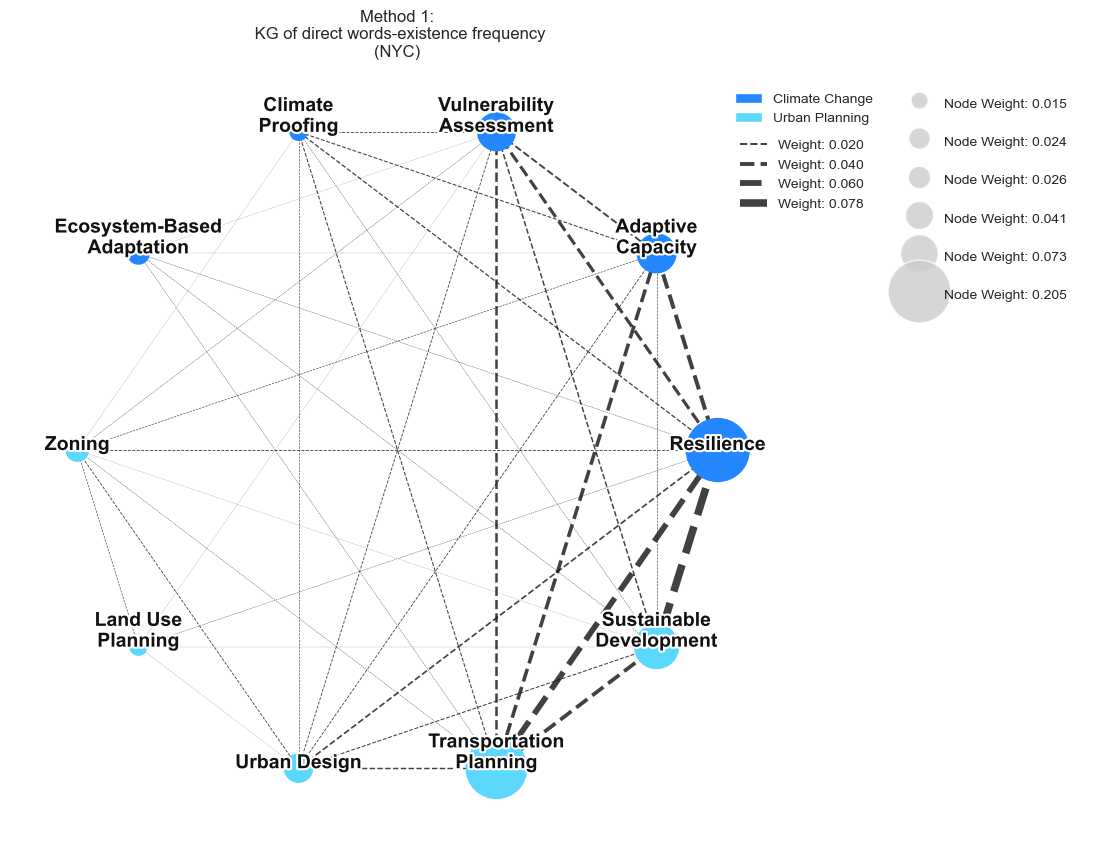

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.patheffects as path_effects
# 假设已经有了 keyword_counts 和 cooccurrence_matrix
import textwrap

# 创建一个空的无向图
G = nx.Graph()

# 添加节点，节点的权重是关键词的出现频率
for keyword, count in keyword_frequency.items():
    G.add_node(keyword, size=count)

# 添加边，边的权重是共现次数
for keyword1, cooccurrences in cooccurrence_matrix.items():
    for keyword2, count in cooccurrences.items():
        if keyword1 != keyword2:  # 避免自环
            G.add_edge(keyword1, keyword2, weight=count)
l=50
k=200
j=70
# 假设 G 中的节点名称与 word_freq 中的键（主题词）相匹配
#node_sizes = [keyword_frequency[node] * 50 for node in G.nodes()]  # 使用 keyword_frequency 中的频率来设置节点大小
node_sizes = [keyword_frequency.get(node, 0) * l if keyword_frequency.get(node, 0) > 0 else 0 for node in G.nodes()]
# 设置边的宽度，按共现次数来调整
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

# 定义自定义顺序列表
custom_order = ['resilience', 'adaptive capacity', 'vulnerability assessment', 'climate proofing', 'ecosystem-based adaptation', 'zoning', 'land use planning', 'urban design', 'transportation planning', 'sustainable development']

# 使用自定义顺序对节点列表进行排序
node_list = list(G.nodes())

# 将节点按照 custom_order 中的顺序排列
node_list.sort(key=lambda x: custom_order.index(x))

# 圆形布局：将节点均匀地分布在圆形上
radius = 1.5  # 控制圆的半径
pos = {}
num_nodes = len(node_list)
for i, node in enumerate(node_list):
    angle = 2 * np.pi * i / num_nodes  # 均匀分布节点位置
    pos[node] = (radius * np.cos(angle), radius * np.sin(angle))

# 绘制图形
plt.figure(figsize=(10, 10))

# 绘制前五个固定节点（深蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    #nodelist=list(extended_seed_topics.keys())[:5],  # 前五个节点
    nodelist=custom_order[:5],
    node_color="#2388FF",
    node_size=[size * k for size in node_sizes[:5]],  # 计算前五个节点的大小
    label="climate adaptation"
)

# 绘制剩余的固定节点（浅蓝色，中心较大）
nx.draw_networkx_nodes(
    G,
    pos,
    #nodelist=list(extended_seed_topics.keys())[5:],
    nodelist=custom_order[5:],# 剩余节点
    node_color="#5CD8FF",
    node_size=[size * k for size in node_sizes[5:]],  # 计算剩余节点的大小
    label="urban planning"
)


# 在绘制标签时，添加白色描边
for node, (x, y) in pos.items():
    weight = f"{keyword_frequency.get(node, 0):.3f}" if keyword_frequency.get(node, 0) > 0 else "0"   # 获取当前节点的权重  # 获取当前节点的权重  # 获取节点的权重
    modified_node = f"{node}"#\n{weight:.2f}
    wrapped_text = textwrap.fill(modified_node.title(), width=15)
    text = plt.text(
        x, y, wrapped_text, fontsize=14, fontweight='bold', ha='center', color='#111111'
    )
    text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='white'),  # 添加白色描边
        path_effects.Normal()  # 恢复正常文字效果
    ])

edges1 = G.edges(data=True)
weights1 = [data['weight'] for _, _, data in edges1]



nx.draw_networkx_edges(
    G,
    pos,
    width=[edge_weight * j for edge_weight in edge_weights],
    alpha=0.8,
    style='--',
    edge_color='#111111')


weights2 = [w for w in weights1 if w > 0]  # 过滤掉所有非正数权重
min_weight, max_weight = min(weights2), max(weights1)

# 不再归一化，直接使用原始权重
example_weights = [min_weight, (min_weight + max_weight) / 4, (min_weight + max_weight) / 2, (min_weight + max_weight) / 4 * 3, max_weight]
example_widths = [min_weight * j, (min_weight + max_weight) / 4 * j, (min_weight + max_weight) / 2 * j, (min_weight + max_weight) / 4 * 3 * j, max_weight * j]


# 添加图例
legend_elements = [
    Patch(facecolor='#2388FF', edgecolor='#ffffff', label='Climate Change'),  # 蓝色固定节点
    Patch(facecolor='#5CD8FF', edgecolor='#ffffff', label='Urban Planning')   # 黄色固定节点
]
# 调整图例中的节点大小计算
legend_node_sizes = [np.sqrt(size*k) for size in node_sizes]  # 根据绘图的node_size计算半径
legend_node_weights = [node_weight/50 for node_weight in node_sizes]

# 对节点权重和大小去重并排序，同时移除 NaN
unique_weights_sizes = sorted(
    {(w, s) for w, s in zip(legend_node_weights, legend_node_sizes) if not np.isnan(w) and not np.isnan(s)}
)
sorted_weights, sorted_sizes = zip(*unique_weights_sizes) if unique_weights_sizes else ([], [])

# 限制图例中最多五个节点，确保头尾都在
max_legend_items = 6

if len(sorted_weights) > max_legend_items:
    # 包含头尾节点
    first_weight, last_weight = sorted_weights[0], sorted_weights[-1]
    first_size, last_size = sorted_sizes[0], sorted_sizes[-1]

    # 从中间节点中等间距选取剩余的节点
    middle_weights = sorted_weights[1:-1]
    middle_sizes = sorted_sizes[1:-1]
    num_middle_items = max_legend_items - 2  # 除去头尾的数量

    if num_middle_items > 0:
        step = max(1, len(middle_weights) // num_middle_items)  # 计算步长
        sampled_indices = list(range(0, len(middle_weights), step))[:num_middle_items]
        middle_weights = [middle_weights[i] for i in sampled_indices]
        middle_sizes = [middle_sizes[i] for i in sampled_indices]
    else:
        middle_weights, middle_sizes = [], []

    # 合并头部、中间和尾部
    sorted_weights =[first_weight] +  middle_weights + [last_weight]
    sorted_sizes = [first_size] + middle_sizes + [last_size]
    # 合并头部、中间和尾部
    #sorted_weights = middle_weights + [last_weight]
    #sorted_sizes =  middle_sizes + [last_size]


# 添加边权重示例
for w, width in zip(example_weights, example_widths):
    legend_elements.append(
        Line2D(
            [0], [0],
            color='#111111',
            alpha=0.8,
            lw=width,
            linestyle='--',
            label=f"Weight: {w:.3f}"
        )
    )
# 添加节点大小图例
node_size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markersize=size,  # 直接使用调整后的半径作为markersize
           markerfacecolor='#CCCCCC',
           alpha=0.8,
           label=f"Node Weight: {weight:.3f}")
    for weight, size in zip(sorted_weights, sorted_sizes)
]
legend_elements.extend(node_size_legend)

# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[:2],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.15, 1),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制节点图例
node_legend = plt.legend(
    handles=legend_elements[3:7],  # 节点相关图例
    loc="upper right",
    bbox_to_anchor=(1.138, 0.94),
    fontsize=10,
    frameon=False,
    borderpad=1.5      # 增加边框和内容之间的填充
)
plt.gca().add_artist(node_legend)  # 手动添加第一个图例
# 绘制边权重图例
plt.legend(
    handles=legend_elements[7:],  # 边权重相关图例
    loc="upper right",
    bbox_to_anchor=(1.4, 1),
    fontsize=10,
    frameon=False,
    labelspacing=1.2,  # 增加标签之间的垂直间距
    handleheight=2,    # 增加句柄（marker）高度
    borderpad=1.5      # 增加边框和内容之间的填充
)
# 显示图形
plt.title('Method 1:\n KG of direct words-existence frequency\n(NYC)')
plt.axis('off')
plt.show()
